In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt
from rich.console import Console

from libdet import Hamiltonian
from detnqs.model import Backflow, RBackflow
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import psr, minsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [2]:
mol = gto.M(
    atom=
    '''
    N   0.53920000,  0.00000000,  0.0000000
    N   -0.539200000,  0.00000000,  0.0000000
    ''',
    # atom=
    # '''
    # O   0.00000000,  0.00000000,  0.00000000
    # H   0.75700000,  0.00000000,  0.58590000
    # H  -0.75700000,  0.00000000,  0.58590000
    # ''',
    # atom=
    # '''
    # Li   3.732, 0.25, 0.0
    # Li   2.0, 0.25, 0.0
    # O  2.866, -0.25, 0.0
    # ''',
    basis="sto-3g",
    unit="Angstrom",
    spin=0,
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -109.099941428008 # N2_631g
# e_fci = -87.892693 # Li2O_sto3g
# e_fci = -76.243769 # H2O_ccpvdz

solver = fci.direct_spin0.FCI(mol)
solver.nroots = 2
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
s2, mult = fci.spin_op.spin_square(ci[0], norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -107.488973088654
FCI energy : -107.640233152150
S^2  : 0.000000


In [3]:
model = RBackflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=32,
    proposal="ham",
    blur=0.5,
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
)

steps = 1000
optimizer = optax.chain(
    psr(shift=1e-2),
    optax.scale(-5e-2)
)

E0609 00:24:04.105737  164657 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0609 00:24:04.116649  163932 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


--------------------------------------------------------------------------------------------------------
Step        Energy         |E-E0|       Var        Acc      ESS      N_u      N_f     alpha    SR cond  
--------------------------------------------------------------------------------------------------------
  0     -107.49461626     1.46e-01    3.14e-01    0.5%     50.3%     114     2120     1.000    4.33e+03 
 10     -107.62105664     1.92e-02    8.31e-03    28.5%    18.4%     351     3547     0.613    1.48e+02 
 20     -107.63491345     5.32e-03    1.45e-02    31.2%    11.0%     459     3597     0.739    9.76e+01 
 30     -107.63875863     1.47e-03    1.95e-02    34.1%    8.8%      446     3601     0.821    2.51e+02 
 40     -107.63920364     1.03e-03    1.62e-02    30.3%    9.4%      447     3603     0.863    1.56e+02 
 50     -107.63999704     2.36e-04    1.70e-03    28.9%    10.5%     433     3588     0.877    1.62e+02 
 60     -107.64006732     1.66e-04    1.53e-03    31.8%

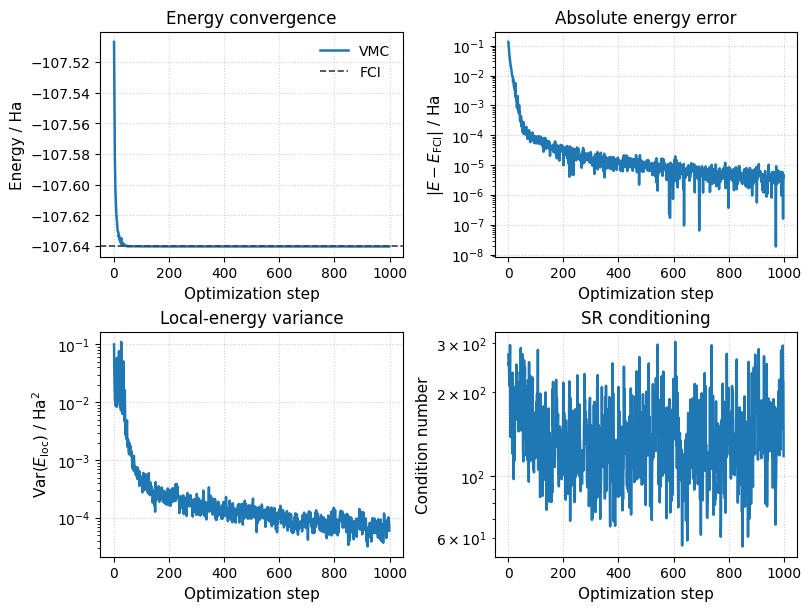

In [4]:
from collections import defaultdict

METRICS = {
    "step":     ("Step",    "d",    5),
    "energy":   ("Energy",  ".8f", 16),
    "error":    ("|E-E0|", ".2e", 10),
    "variance": ("Var",    ".2e", 10),
    "accept":   ("Acc",    ".1%",  7),
    "ess_frac": ("ESS",    ".1%",  7),
    "n_unique": ("N_u",    ".0f",  7),
    "n_eval":   ("N_f",    ".0f",  7),
    "alpha":    ("alpha",  ".3f",  7),
    "sr_cond":  ("SR cond", ".2e", 10),
}

header = "  ".join(f"{label:^{width}}" for label, _, width in METRICS.values())
line = "-" * len(header)
print(line, header, line, sep="\n")


vmc = VMC.init(state, optimizer)
history = []
total_times = defaultdict(float)

for step in range(steps):
    stats = dict(vmc.step())
    stats["step"] = step
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(stats)

    for key, value in stats.items():
        if key.startswith("time_"):
            total_times[key.removeprefix("time_")] += float(value)

    if step % 10 == 0 or step == steps - 1:
        row = []
        for key, (_, fmt, width) in METRICS.items():
            value = stats.get(key, np.nan)
            text = f"{int(value):{fmt}}" if fmt == "d" else f"{float(value):{fmt}}"
            row.append(f"{text:^{width}}")
        print("  ".join(row))

print(line)

if total_times:
    times = sorted(
        (item for item in total_times.items() if item[0] != "total"),
        key=lambda item: item[1],
        reverse=True,
    )
    print("Time:", "  ".join(f"{key}={value:.2f}s" for key, value in times))
    print(line)


# Convert history to arrays
hist = {
    key: np.asarray([record.get(key, np.nan) for record in history], dtype=float)
    for key in METRICS
}

mask = hist["step"] > 0
x = hist["step"][mask]

energy = hist["energy"][mask]
error = np.clip(hist["error"][mask], 1e-16, None)
variance = np.clip(hist["variance"][mask], 1e-16, None)
sr_cond = np.where(hist["sr_cond"][mask] > 0, hist["sr_cond"][mask], np.nan)


# Plot
fig, axes = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
axes = axes.ravel()

ax = axes[0]
ax.plot(x, energy, lw=1.8, label="VMC")
ax.axhline(e_fci, ls="--", lw=1.2, color="0.25", label="FCI")
ax.set(
    title="Energy convergence",
    xlabel="Optimization step",
    ylabel="Energy / Ha",
)
ax.legend(frameon=False)

ax = axes[1]
ax.semilogy(x, error, lw=1.8)
ax.set(
    title="Absolute energy error",
    xlabel="Optimization step",
    ylabel=r"$|E - E_\mathrm{FCI}|$ / Ha",
)

ax = axes[2]
ax.semilogy(x, variance, lw=1.8)
ax.set(
    title="Local-energy variance",
    xlabel="Optimization step",
    ylabel=r"$\mathrm{Var}(E_\mathrm{loc})$ / Ha$^2$",
)

ax = axes[3]
if np.isfinite(sr_cond).any():
    ax.semilogy(x, sr_cond, lw=1.8)
else:
    ax.text(
        0.5, 0.5, "SR condition unavailable",
        ha="center", va="center",
        transform=ax.transAxes,
    )
ax.set(
    title="SR conditioning",
    xlabel="Optimization step",
    ylabel="Condition number",
)

for ax in axes:
    ax.grid(True, which="major", ls=":", alpha=0.6)
    ax.tick_params(labelsize=10)
    ax.title.set_size(12)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)

plt.show()